1. Initial Cleansing & Exploaration

#### First, you do some initial data cleaning and exploration. This includes inspecting the dataset, understanding the variables, checking distributions, correlations, missing values, and removing columns that clearly cannot be used for prediction (IDs, post-incident variables, timestamps of the incident itself, etc.). You have already done some of this. 

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df_new = pd.read_excel('C:/Users/pw347789/OneDrive - Oxfordshire County Council/Desktop/Cambridge Spark/PROJECT/HomeSafety_2/RawData/PYTHON_OUTPUTS/df_new.xlsx')

In [3]:
df = df_new.copy()
df

,Unnamed: 0,Addressbase UPRN,ABP_Classification_Desc,ABP_Classification_Code,Tenure_Desc,AgeBracket_EldParent,(H) Age - Fine,(H) Presence of Elderly Parent,(H) Number of Adults in Household,(H) Family Lifestage v3,...,Property_Description,Description,Property_Code,VictimsInvolved,VictimType,WasRescued,Victim_Category,EvacuationAssistanceInvolved,EquipmentUsed,Incident?
0,0,10002188486,Detached,RD02,Owner,76+,11,0,4,12,...,0,0,0,0,0,0,0,0,0,N
1,1,10002188492,Semi-Detached,RD03,Owner,61 - 65,8,0,2,9,...,0,0,0,0,0,0,0,0,0,N
2,2,10002188491,Semi-Detached,RD03,Owner,56 - 60,7,0,3,8,...,0,0,0,0,0,0,0,0,0,N
3,3,10002188489,Semi-Detached,RD03,Owner,66 - 70,9,0,2,12,...,0,0,0,0,0,0,0,0,0,N
4,4,10002188488,Semi-Detached,RD03,Rental,46 - 50,5,0,2,10,...,0,0,0,0,0,0,0,0,0,N
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
82309,82309,10033008730,Self Contained Flat (Includes Maisonette / Apa...,RD06,Council/HA,56 - 60,7,0,1,8,...,0,0,0,0,0,0,0,0,0,N
82310,82310,10033008731,Self Contained Flat (Includes Maisonette / Apa...,RD06,Council/HA,76+,11,0,1,11,...,0,0,0,0,0,0,0,0,0,N
82311,82311,10093775878,Self Contained Flat (Includes Maisonette / Apa...,RD06,Council/HA,46 - 50,5,0,2,10,...,0,0,0,0,0,0,0,0,0,N
82312,82312,10033005849,Semi-Detached,RD03,Rental,76+,11,0,1,10,...,0,0,0,0,0,0,0,0,0,N


In [4]:
df.shape

(82314, 50)

In [5]:
df.rename(columns = {'Incident?':'INCIDENT'}, inplace = True)
df.head(2)

,Unnamed: 0,Addressbase UPRN,ABP_Classification_Desc,ABP_Classification_Code,Tenure_Desc,AgeBracket_EldParent,(H) Age - Fine,(H) Presence of Elderly Parent,(H) Number of Adults in Household,(H) Family Lifestage v3,...,Property_Description,Description,Property_Code,VictimsInvolved,VictimType,WasRescued,Victim_Category,EvacuationAssistanceInvolved,EquipmentUsed,INCIDENT
0,0,10002188486,Detached,RD02,Owner,76+,11,0,4,12,...,0,0,0,0,0,0,0,0,0,N
1,1,10002188492,Semi-Detached,RD03,Owner,61 - 65,8,0,2,9,...,0,0,0,0,0,0,0,0,0,N


In [6]:
df['INCIDENT'].value_counts(normalize = True)

N    0.969203
Y    0.030797
Name: INCIDENT, dtype: float64

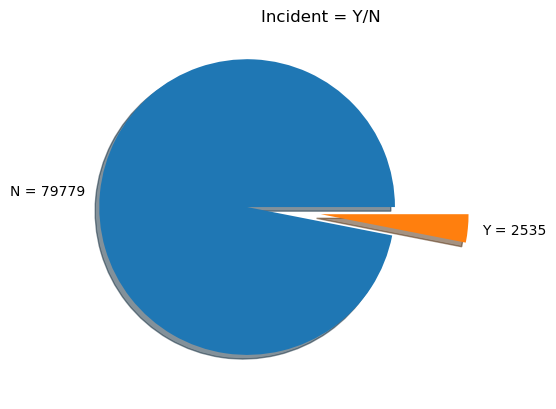

In [7]:
mylabels = [f"N = {df['INCIDENT'].value_counts()[0]}", f"Y = {df['INCIDENT'].value_counts()[1]}"]
myexplode = [0.5, 0]
plt.pie(df['INCIDENT'].value_counts(), labels = mylabels, explode = myexplode, shadow = True)
plt.title('Incident = Y/N')


plt.show()

## Note:
### The target feature ['INCIDENT'] is very far from being balanced.
##### When test_train_split >> Remember to set stratify = y

## .................

#### 1(a) Remove Redundant columns

In [8]:
df = df.drop(columns=['Addressbase UPRN','Unnamed: 0','Easting', 'Northing', 'CREATION_DATE',
       'FRSIncidentIdentifier', 'Year', 'Fiscal_Year', 'TimeOfCall',
       'ResponsiblePartyStationId', 'IncidentCategory', 'Property_Type',
       'Property_Description', 'Description', 'Property_Code',
       'VictimsInvolved', 'VictimType', 'WasRescued', 'Victim_Category',
       'EvacuationAssistanceInvolved', 'EquipmentUsed','ABP_Classification_Desc',
        'Household Acorn Category Description','Household Acorn Type Description_x',
        'Household Acorn Group Description', 'Household Acorn Type Description_y',
        '(H) Water Poverty Flag', '(H) Fuel Poverty v2 Flag','Dependent Locality',
                      'Town','Station_Ground_Code',
                      '(H) Presence of Elderly Parent','AgeBracket_EldParent',
                      'Output Area'
                      
                     ])

In [9]:
df.shape

(82314, 16)

In [10]:
df.columns
df.head(2)

,ABP_Classification_Code,Tenure_Desc,(H) Age - Fine,(H) Number of Adults in Household,(H) Family Lifestage v3,(H) Length of Residency,(H) Affluence v2,(H) Number of Children v3,(H) Household Income v3 - Bands,Household Acorn Category,Household Acorn Type_x,LSOA11CD,Local Custodian Name,Household Acorn Group,Household Acorn Type_y,INCIDENT
0,RD02,Owner,11,4,12,11,19,0,8,1,5,E01028762,West Oxfordshire,1,2,N
1,RD03,Owner,8,2,9,11,16,0,3,1,9,E01028762,West Oxfordshire,2,3,N


## 1(b) Missing values?

In [11]:
print(df.isnull().sum())

ABP_Classification_Code              0
Tenure_Desc                          0
(H) Age - Fine                       0
(H) Number of Adults in Household    0
(H) Family Lifestage v3              0
(H) Length of Residency              0
(H) Affluence v2                     0
(H) Number of Children v3            0
(H) Household Income v3 - Bands      0
Household Acorn Category             0
Household Acorn Type_x               0
LSOA11CD                             0
Local Custodian Name                 0
Household Acorn Group                0
Household Acorn Type_y               0
INCIDENT                             0
dtype: int64


## Comment:
#### No null values are present.
#### Would it be worth performing Imputation here in case of null values being present in future datasets?

df.head(2)

# 1(c): Check distributions

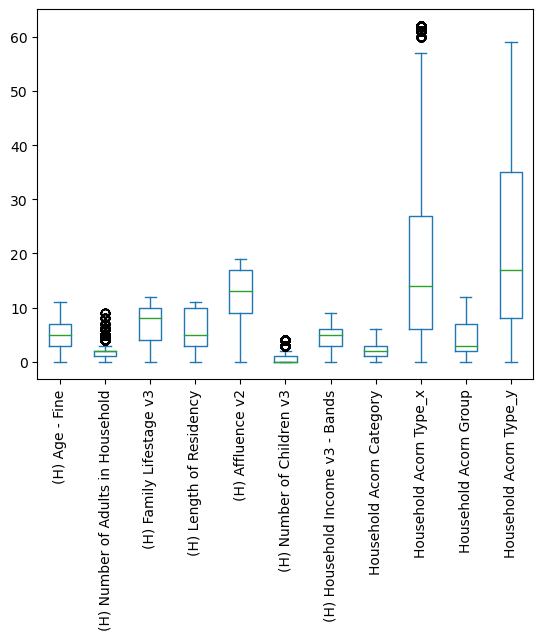

In [12]:
ax = df.plot.box()
plt.xticks(rotation=90)
plt.show()

In [13]:
df.dtypes

ABP_Classification_Code              object
Tenure_Desc                          object
(H) Age - Fine                        int64
(H) Number of Adults in Household     int64
(H) Family Lifestage v3               int64
(H) Length of Residency               int64
(H) Affluence v2                      int64
(H) Number of Children v3             int64
(H) Household Income v3 - Bands       int64
Household Acorn Category              int64
Household Acorn Type_x                int64
LSOA11CD                             object
Local Custodian Name                 object
Household Acorn Group                 int64
Household Acorn Type_y                int64
INCIDENT                             object
dtype: object

### Comment:
#### These features are Ordinal categories -- do they require some sort of Scaling/Normalisation?

## 1(d): Correlation between features?

### for the .corr() function to operate, the target feature must be converted to numeric format:

### Replace the TARGET varable from Y/N to 0/1:¶

In [14]:
df['INCIDENT'].replace('N',0, inplace = True)
df['INCIDENT'].replace('Y',1, inplace = True)

df['INCIDENT'].dtype

dtype('int64')

In [15]:
from pandas.plotting import scatter_matrix

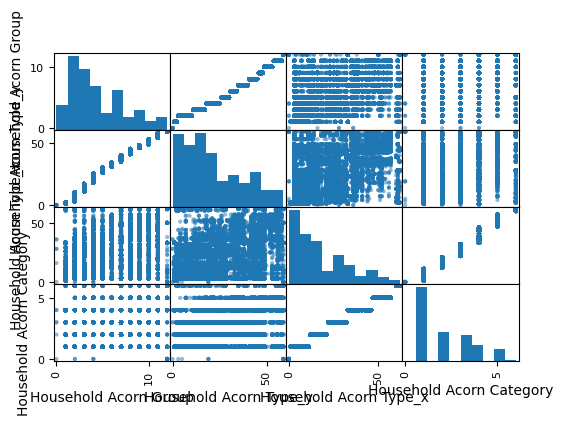

In [16]:
## for those features with positive correlation coefficients:

attributes = ['Household Acorn Group','Household Acorn Type_y','Household Acorn Type_x','Household Acorn Category']
scatter_matrix(df[attributes], figsize = (6,4))
#plt.title('features with POSITIVE correlation coefficients')
plt.show()

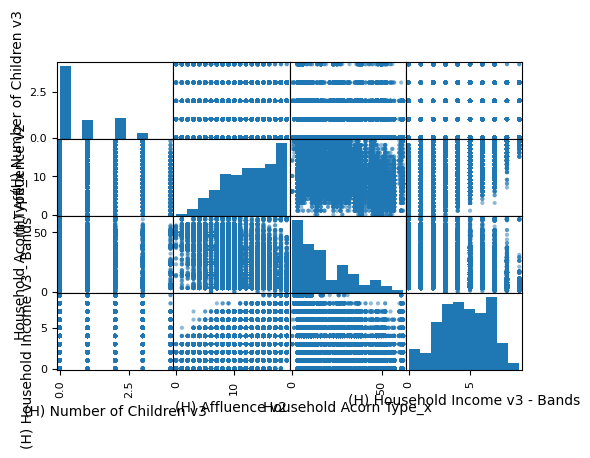

In [17]:
## for those features with NEGATIVE correlation coefficients:

attributes = ['(H) Number of Children v3','(H) Affluence v2','Household Acorn Type_x','(H) Household Income v3 - Bands']
scatter_matrix(df[attributes], figsize = (6,4))
#plt.title('features with NEGATIVE correlation coefficients')

plt.show()

### Using the Pearson Correlation:

In [18]:
corr_pearson = df.corr()
corr_pearson['INCIDENT'].sort_values(ascending = False)

INCIDENT                             1.000000
Household Acorn Group                0.074549
Household Acorn Type_y               0.071001
Household Acorn Type_x               0.050459
Household Acorn Category             0.044154
(H) Age - Fine                       0.017898
(H) Length of Residency              0.016212
(H) Family Lifestage v3              0.007159
(H) Number of Adults in Household   -0.005767
(H) Number of Children v3           -0.026177
(H) Affluence v2                    -0.044805
(H) Household Income v3 - Bands     -0.054997
Name: INCIDENT, dtype: float64

Text(0.5, 1.0, 'Pearson Corr()')

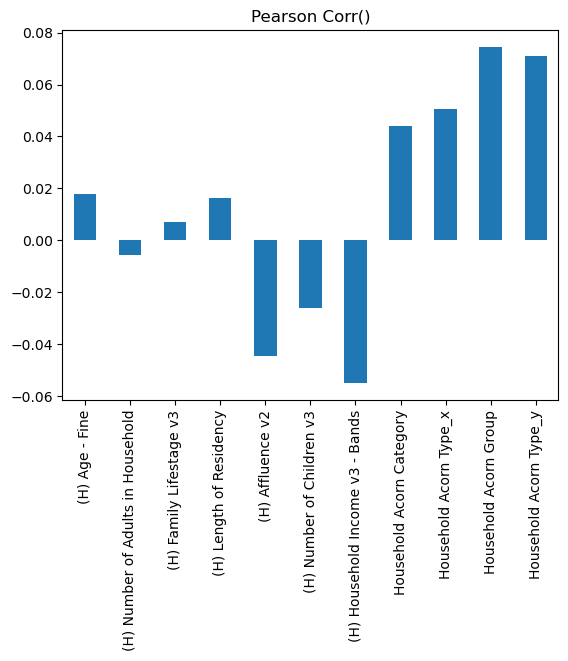

In [19]:
corr_pearson = df.corr()
corr_pearson['INCIDENT']
corr_pearson['INCIDENT'][:-1].plot(kind = 'bar')
plt.title('Pearson Corr()')

<AxesSubplot:>

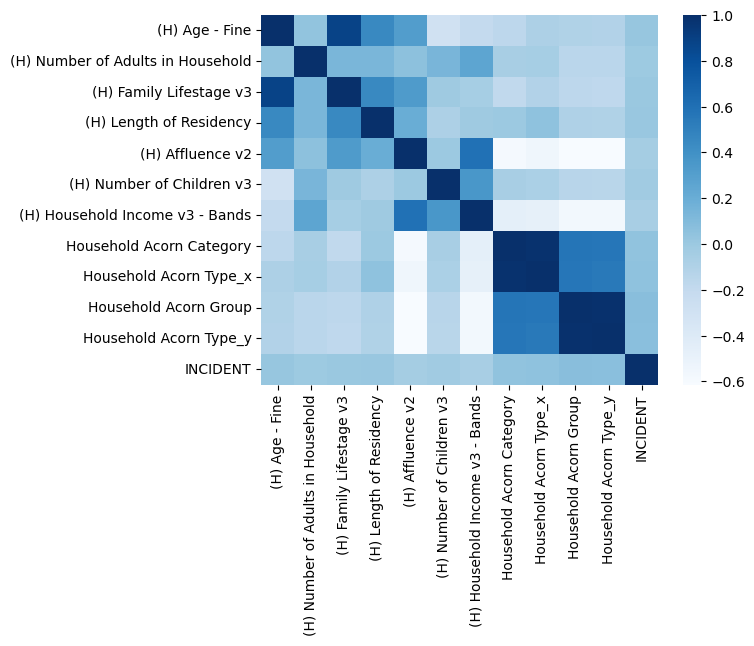

In [20]:
# calculate the correlation matrix on the numeric columns
corr_pearson = df.select_dtypes('number').corr()

# plot the heatmap
sns.heatmap(corr_pearson, cmap="Blues")

### Using the Spearman Correlation:

In [21]:
corr_spearman = df.corr('spearman')
corr_spearman['INCIDENT'].sort_values(ascending = False)

INCIDENT                             1.000000
Household Acorn Type_y               0.058500
Household Acorn Group                0.058305
Household Acorn Type_x               0.039198
Household Acorn Category             0.035277
(H) Age - Fine                       0.015238
(H) Length of Residency              0.014911
(H) Family Lifestage v3              0.009161
(H) Number of Adults in Household   -0.017104
(H) Number of Children v3           -0.028178
(H) Affluence v2                    -0.037921
(H) Household Income v3 - Bands     -0.052295
Name: INCIDENT, dtype: float64

Text(0.5, 1.0, 'Spearman Corr()')

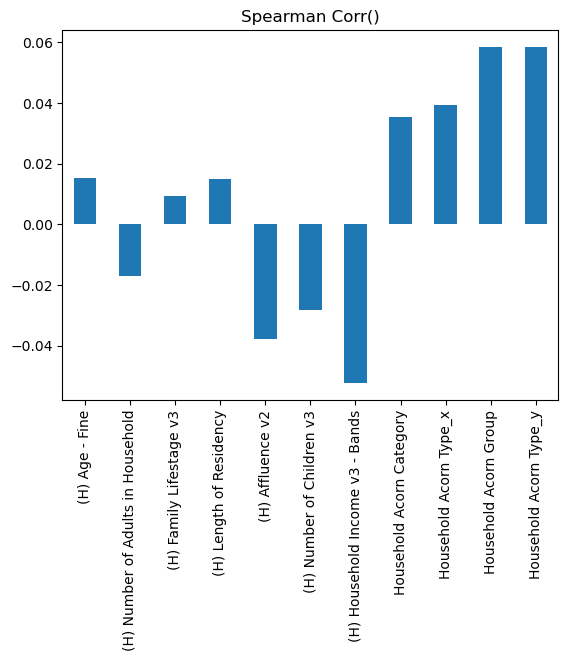

In [22]:
corr_spearman = df.corr('spearman')
corr_spearman['INCIDENT']
corr_spearman['INCIDENT'][:-1].plot(kind = 'bar')
plt.title('Spearman Corr()')

<AxesSubplot:>

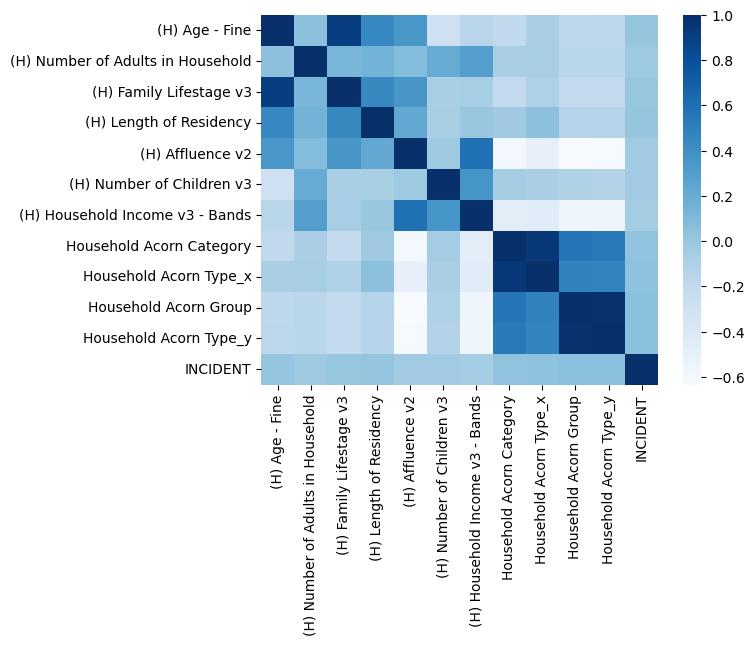

In [23]:
# calculate the correlation matrix on the numeric columns
corr_spearman = df.select_dtypes('number').corr('spearman')

# plot the heatmap
sns.heatmap(corr_spearman, cmap="Blues")

In [24]:
#corrs = corr_p.merge(corr_sp, shared_index = True)
corr_pearson_df = pd.DataFrame(corr_pearson['INCIDENT'])
corr_pearson_df.rename(columns = {'INCIDENT': 'PEARSON_COEFFICIENT'}, inplace = True)

corr_spearman_df = pd.DataFrame(corr_spearman['INCIDENT'])
corr_spearman_df.rename(columns = {'INCIDENT': 'SPEARMAN_COEFFICIENT'}, inplace = True)

In [25]:
corr_pearson_df

,PEARSON_COEFFICIENT
(H) Age - Fine,0.017898
(H) Number of Adults in Household,-0.005767
(H) Family Lifestage v3,0.007159
(H) Length of Residency,0.016212
(H) Affluence v2,-0.044805
(H) Number of Children v3,-0.026177
(H) Household Income v3 - Bands,-0.054997
Household Acorn Category,0.044154
Household Acorn Type_x,0.050459
Household Acorn Group,0.074549


In [26]:
corr_spearman_df

,SPEARMAN_COEFFICIENT
(H) Age - Fine,0.015238
(H) Number of Adults in Household,-0.017104
(H) Family Lifestage v3,0.009161
(H) Length of Residency,0.014911
(H) Affluence v2,-0.037921
(H) Number of Children v3,-0.028178
(H) Household Income v3 - Bands,-0.052295
Household Acorn Category,0.035277
Household Acorn Type_x,0.039198
Household Acorn Group,0.058305


In [27]:
corrs_df = pd.concat([corr_pearson_df, corr_spearman_df], axis=1)
corrs_df

,PEARSON_COEFFICIENT,SPEARMAN_COEFFICIENT
(H) Age - Fine,0.017898,0.015238
(H) Number of Adults in Household,-0.005767,-0.017104
(H) Family Lifestage v3,0.007159,0.009161
(H) Length of Residency,0.016212,0.014911
(H) Affluence v2,-0.044805,-0.037921
(H) Number of Children v3,-0.026177,-0.028178
(H) Household Income v3 - Bands,-0.054997,-0.052295
Household Acorn Category,0.044154,0.035277
Household Acorn Type_x,0.050459,0.039198
Household Acorn Group,0.074549,0.058305


<AxesSubplot:>

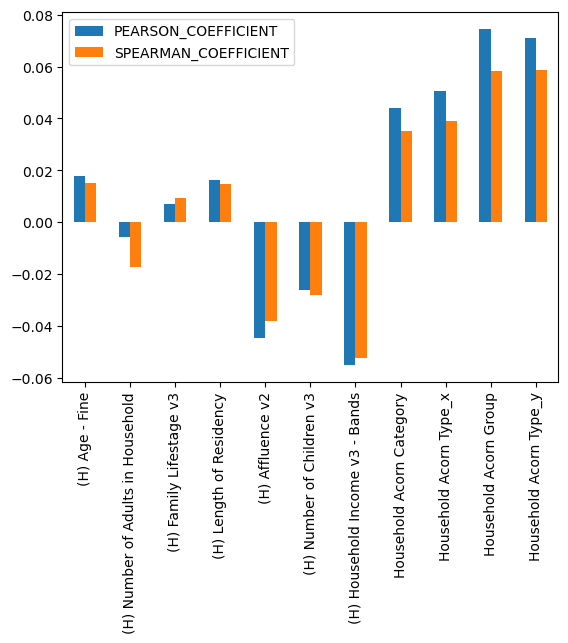

In [28]:
corrs_df[:-1].plot(kind = 'bar')

## The extremely low correlation coeffiicents between MAIN FEATURES (X) and the TARGET FEATURES (y) demonstrate that a linear correlation will not be suitable for modelling this data.


# ....................

# PART 2:
# 2(a) SPLIT THE DATA:
#### Next, you define the target and features. This means separating the dataset into the input variables (X) and the target variable (y), which in your case is the Incident column.

In [29]:
df = pd.DataFrame(df)
df.columns

Index(['ABP_Classification_Code', 'Tenure_Desc', '(H) Age - Fine',
       '(H) Number of Adults in Household', '(H) Family Lifestage v3',
       '(H) Length of Residency', '(H) Affluence v2',
       '(H) Number of Children v3', '(H) Household Income v3 - Bands',
       'Household Acorn Category', 'Household Acorn Type_x', 'LSOA11CD',
       'Local Custodian Name', 'Household Acorn Group',
       'Household Acorn Type_y', 'INCIDENT'],
      dtype='object')

In [30]:
cols = []
for c in df.columns:
    cols.append(c)
cols

['ABP_Classification_Code',
 'Tenure_Desc',
 '(H) Age - Fine',
 '(H) Number of Adults in Household',
 '(H) Family Lifestage v3',
 '(H) Length of Residency',
 '(H) Affluence v2',
 '(H) Number of Children v3',
 '(H) Household Income v3 - Bands',
 'Household Acorn Category',
 'Household Acorn Type_x',
 'LSOA11CD',
 'Local Custodian Name',
 'Household Acorn Group',
 'Household Acorn Type_y',
 'INCIDENT']

In [31]:
# target data
y = df[cols[-1]]
y

0        0
1        0
2        0
3        0
4        0
        ..
82309    0
82310    0
82311    0
82312    0
82313    0
Name: INCIDENT, Length: 82314, dtype: int64

In [32]:
X_cols = cols[0:len(cols)-1]
X = df[df.columns.intersection(X_cols)]
X.shape
X.head(2)

,ABP_Classification_Code,Tenure_Desc,(H) Age - Fine,(H) Number of Adults in Household,(H) Family Lifestage v3,(H) Length of Residency,(H) Affluence v2,(H) Number of Children v3,(H) Household Income v3 - Bands,Household Acorn Category,Household Acorn Type_x,LSOA11CD,Local Custodian Name,Household Acorn Group,Household Acorn Type_y
0,RD02,Owner,11,4,12,11,19,0,8,1,5,E01028762,West Oxfordshire,1,2
1,RD03,Owner,8,2,9,11,16,0,3,1,9,E01028762,West Oxfordshire,2,3


#### After defining the X, y features:
#### ...perform a train/test split. The reason we do this relatively early is so that part of the data remains completely unseen during training. This allows us to properly evaluate whether the model generalises well.

In [33]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size = 0.2,stratify = y)

In [34]:
X.shape

(82314, 15)

In [35]:
X_train.shape

(65851, 15)

In [36]:
1-(X_train.shape[0]/X.shape[0])

0.20000242972033921

# PART 3: FEATURE ENGINEERING
Then comes feature engineering and preprocessing. This includes things like one-hot encoding categorical variables and scaling or normalising numeric variables. In practice, these transformations are fitted using the training data and then applied to the test data. The goal is to avoid introducing bias or “data leakage” from the test set.

## NOTE: Any Feature engineering takes place on the X_train dataset

In [37]:
X_train.head(2)

,ABP_Classification_Code,Tenure_Desc,(H) Age - Fine,(H) Number of Adults in Household,(H) Family Lifestage v3,(H) Length of Residency,(H) Affluence v2,(H) Number of Children v3,(H) Household Income v3 - Bands,Household Acorn Category,Household Acorn Type_x,LSOA11CD,Local Custodian Name,Household Acorn Group,Household Acorn Type_y
9446,RD06,Owner,3,1,7,8,10,1,3,1,7,E01028510,Cherwell,8,44
22100,RD03,Owner,4,2,6,9,15,2,7,1,6,E01028757,Vale of White Horse,2,5


In [38]:
X_train.dtypes

ABP_Classification_Code              object
Tenure_Desc                          object
(H) Age - Fine                        int64
(H) Number of Adults in Household     int64
(H) Family Lifestage v3               int64
(H) Length of Residency               int64
(H) Affluence v2                      int64
(H) Number of Children v3             int64
(H) Household Income v3 - Bands       int64
Household Acorn Category              int64
Household Acorn Type_x                int64
LSOA11CD                             object
Local Custodian Name                 object
Household Acorn Group                 int64
Household Acorn Type_y                int64
dtype: object

In [39]:
# feature == float64
X_train_floats = X_train.dtypes[X_train.dtypes == 'float64']
print(f'The are {len(X_train_floats)} float64 formats present >>>') 

The are 0 float64 formats present >>>


### feature == integer

In [40]:
# feature == integer

X_train_int = X_train.dtypes[X_train.dtypes == 'int64']
X_train_int = X_train.select_dtypes('int64')
print(f'The are {X_train_int.shape[1]} float64 formats present >>>') 

X_train_int.head(4)

The are 11 float64 formats present >>>


,(H) Age - Fine,(H) Number of Adults in Household,(H) Family Lifestage v3,(H) Length of Residency,(H) Affluence v2,(H) Number of Children v3,(H) Household Income v3 - Bands,Household Acorn Category,Household Acorn Type_x,Household Acorn Group,Household Acorn Type_y
9446,3,1,7,8,10,1,3,1,7,8,44
22100,4,2,6,9,15,2,7,1,6,2,5
24966,7,2,10,4,19,1,5,1,3,2,5
27085,3,2,5,8,16,0,7,3,25,2,7


### Whereby it's possible to view the histograms of the int64 format features:

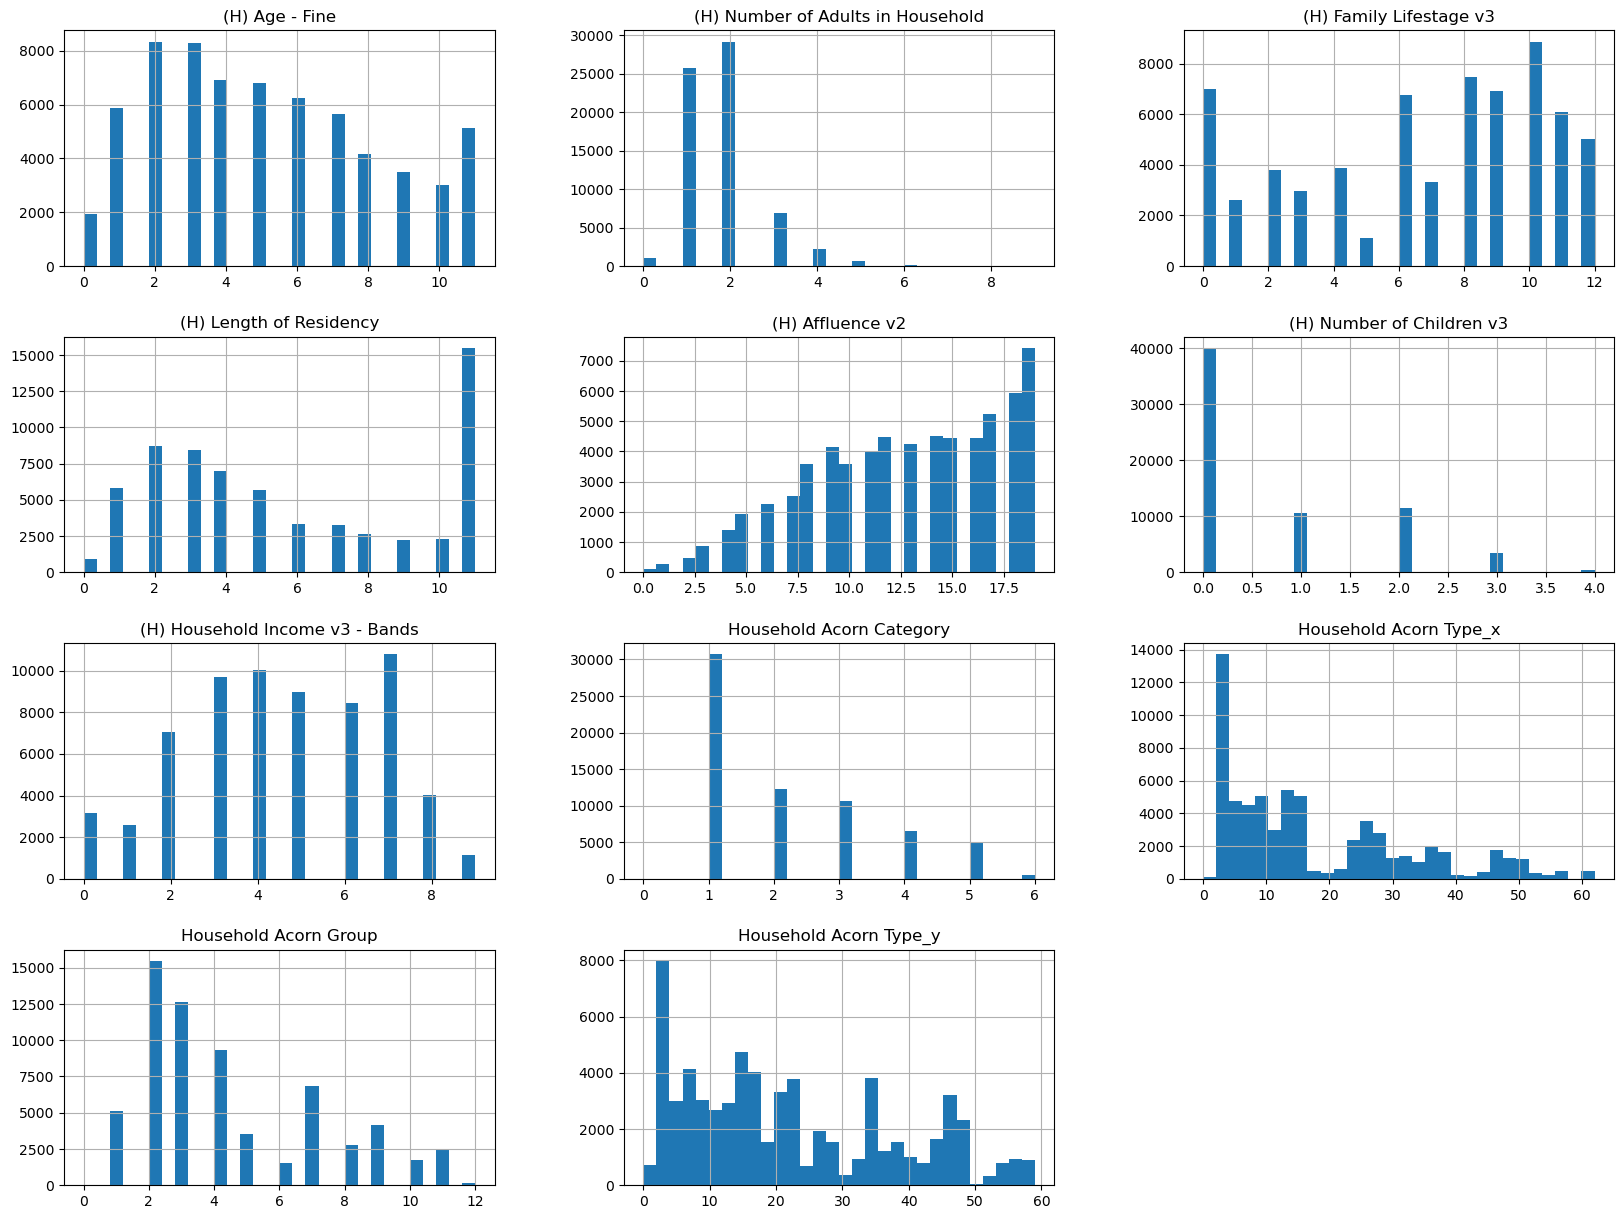

In [41]:
X_train_int.hist(bins = 30,figsize = (20,15));
plt.show()

### As well as viewing the distributions of the int64 features:

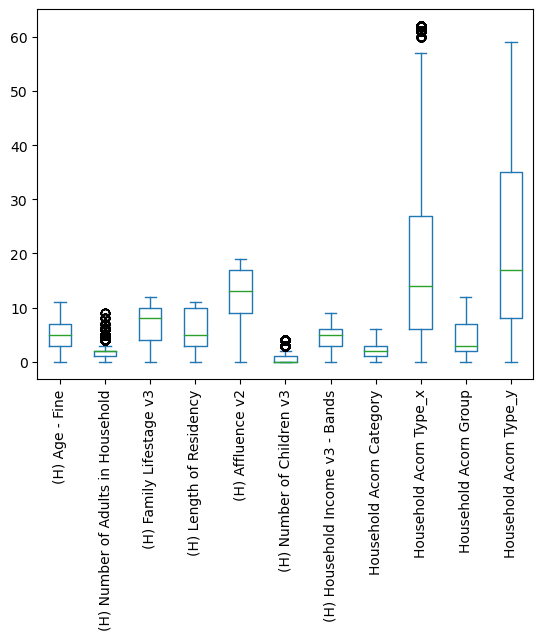

In [42]:
ax = X_train_int.plot.box()
plt.xticks(rotation=90)
plt.show()

### feature == object

In [43]:
# feature == object

X_train_obj = X_train.dtypes[X_train.dtypes == 'object']
X_train_obj = X_train.select_dtypes('object')
print(f'The are {X_train_obj.shape[1]} float64 formats present >>>') 

print(f'X_train.shape = {X_train_obj.shape}')
X_train_obj.head(4)


The are 4 float64 formats present >>>
X_train.shape = (65851, 4)


,ABP_Classification_Code,Tenure_Desc,LSOA11CD,Local Custodian Name
9446,RD06,Owner,E01028510,Cherwell
22100,RD03,Owner,E01028757,Vale of White Horse
24966,RD02,Owner,E01028751,Vale of White Horse
27085,RD04,Owner,E01033306,Vale of White Horse


In [44]:

for col in X_train_obj.columns:
    print(f'{col}: {X_train_obj[col].nunique()} unique values')
#X_train_obj['ABP_Classification_Code'].value_counts()

ABP_Classification_Code: 4 unique values
Tenure_Desc: 3 unique values
LSOA11CD: 399 unique values
Local Custodian Name: 5 unique values


In [45]:
X_train_obj[['LSOA11CD']].info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 65851 entries, 9446 to 44235
Data columns (total 1 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   LSOA11CD  65851 non-null  object
dtypes: object(1)
memory usage: 1.0+ MB


### Comment:
##### LSOA11CD: 401 unique values. which is too much for OneHotEncoding as it will produce a sparse matrix of 401 columns
##### Perhaps Ordinal Encoding will be suitable for LSOA11CD?

In [46]:
from sklearn.preprocessing import OrdinalEncoder

In [47]:
ordinal_encoder = OrdinalEncoder()

LSOA = X_train_obj[['LSOA11CD']]
LSOA_ord_enc = ordinal_encoder.fit(LSOA)
cats = ordinal_encoder.categories_
cats
LSOA_ord_enc = ordinal_encoder.transform(LSOA)
LSOA_ord_enc

array([[ 83.],
       [319.],
       [313.],
       ...,
       [391.],
       [ 14.],
       [  2.]])

In [48]:
LSOA_ord_encoded_df = pd.DataFrame(LSOA_ord_enc)
LSOA_ord_encoded_df.rename(columns={0: 'LSOA_ord_enc'}, inplace = True)
print(f'LSOA_ord_encoded_df.shape = {LSOA_ord_encoded_df.shape}')
LSOA_ord_encoded_df

LSOA_ord_encoded_df.shape = (65851, 1)


,LSOA_ord_enc
0,83.0
1,319.0
2,313.0
3,398.0
4,177.0
...,...
65846,374.0
65847,168.0
65848,391.0
65849,14.0


In [49]:


X_t= pd.merge(X_train_obj, LSOA_ord_encoded_df, left_index=True, right_index=True, how ='inner')


#X_t= X_train_obj.merge(X_train_obj, LSOA_ord_encoded_df)
print(f'X_t.shape = {X_t.shape}')

X_t

X_t.isnull().sum()
#LSOA_ord['LSOA_ord_enc'].max()

X_t.shape = (52656, 5)


ABP_Classification_Code    0
Tenure_Desc                0
LSOA11CD                   0
Local Custodian Name       0
LSOA_ord_enc               0
dtype: int64

In [50]:
LSOA11CD_nulls = X_t[X_t['LSOA_ord_enc'].isnull()]#[['LSOA11CD','LSOA_ord_enc']]

In [51]:
#LSOA11CD_nulls.to_excel('C:/Users/pw347789/OneDrive - Oxfordshire County Council/Desktop/Cambridge Spark/PROJECT/HomeSafety_2/RawData/PYTHON_OUTPUTS/LSOA11CD_Ordinal_Encoding_issue/1.xlsx')

In [52]:
LSOA11CD_nulls

,ABP_Classification_Code,Tenure_Desc,LSOA11CD,Local Custodian Name,LSOA_ord_enc


In [53]:
LSOA11CD_nulls['LSOA11CD'].nunique()

0

In [54]:
X_t

,ABP_Classification_Code,Tenure_Desc,LSOA11CD,Local Custodian Name,LSOA_ord_enc
9446,RD06,Owner,E01028510,Cherwell,13.0
22100,RD03,Owner,E01028757,Vale of White Horse,14.0
24966,RD02,Owner,E01028751,Vale of White Horse,128.0
27085,RD04,Owner,E01033306,Vale of White Horse,20.0
60918,RD02,Owner,E01028611,South Oxfordshire,320.0
...,...,...,...,...,...
39824,RD03,Owner,E01028422,Cherwell,34.0
15151,RD03,Council/HA,E01028602,South Oxfordshire,82.0
41319,RD04,Owner,E01032950,West Oxfordshire,335.0
35692,RD03,Owner,E01028438,Cherwell,1.0


In [55]:
65851-52681

13170

## Comment:
#### Not very good at all, this method appears to only encode 20 out of the 400 categories.

#### After all the 'order' for the feature is not important
#### Next the LabelEncoder method is attempted:


# LabelEncoder

In [56]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()

In [57]:
#le.fit([1, 2, 2, 6])
#le.classes_
#le.transform([1, 1, 2, 6])
#le.inverse_transform([0, 0, 1, 2])

In [58]:
LSOA_list = list(set(X_train_obj['LSOA11CD']))
#LSOA_list
le.fit(LSOA_list)

LabelEncoder()

In [59]:
#le.classes_

In [60]:
#X_train_obj['LSOA11CD']
LSOA_labelled = le.transform(X_train_obj['LSOA11CD'])
LSOA_labelled
LSOA_labelled_df = pd.DataFrame(LSOA_labelled)
LSOA_labelled_df.rename(columns = {0:'LSOA_labelled'}, inplace = True)
LSOA_labelled_df.value_counts()


LSOA_labelled
2                2057
48               1462
289               947
386               897
82                839
                 ... 
270                 2
45                  1
257                 1
90                  1
367                 1
Length: 399, dtype: int64

In [61]:
le.inverse_transform(LSOA_labelled)

array(['E01028510', 'E01028757', 'E01028751', ..., 'E01032950',
       'E01028438', 'E01028424'], dtype='<U9')

In [62]:
X_t_obj= pd.merge(X_train_obj, LSOA_labelled_df, left_index=True, right_index=True, how ='inner')

In [63]:
X_t_obj.isnull().sum()

ABP_Classification_Code    0
Tenure_Desc                0
LSOA11CD                   0
Local Custodian Name       0
LSOA_labelled              0
dtype: int64

In [64]:
X_t_obj

,ABP_Classification_Code,Tenure_Desc,LSOA11CD,Local Custodian Name,LSOA_labelled
9446,RD06,Owner,E01028510,Cherwell,13
22100,RD03,Owner,E01028757,Vale of White Horse,14
24966,RD02,Owner,E01028751,Vale of White Horse,128
27085,RD04,Owner,E01033306,Vale of White Horse,20
60918,RD02,Owner,E01028611,South Oxfordshire,320
...,...,...,...,...,...
39824,RD03,Owner,E01028422,Cherwell,34
15151,RD03,Council/HA,E01028602,South Oxfordshire,82
41319,RD04,Owner,E01032950,West Oxfordshire,335
35692,RD03,Owner,E01028438,Cherwell,1


### Although this actually encodes the LSOA11CD feature, it produces 13170 nulls values.

### We make two versions:
## X_train_obj  >>  we drop the LSOA11CD feature and carry on without it.
## X_train_LSOA_enc >> we keep the encoded LSOA and see if it has any advantages

In [65]:
X_train_obj = X_train_obj.drop(['LSOA11CD'], axis=1)

In [66]:
X_train_obj.columns

Index(['ABP_Classification_Code', 'Tenure_Desc', 'Local Custodian Name'], dtype='object')

In [67]:
X_train_LSOA_enc = X_t_obj 

In [68]:
X_train_LSOA_enc.shape,X_train_LSOA_enc.columns

((52656, 5),
 Index(['ABP_Classification_Code', 'Tenure_Desc', 'LSOA11CD',
        'Local Custodian Name', 'LSOA_labelled'],
       dtype='object'))

### For the other X_train objects  do some: OneHotEncoding:

# OneHotEncoding:

In [69]:
from sklearn.preprocessing import OneHotEncoder

ohe = OneHotEncoder(handle_unknown = 'ignore', sparse = False)
X_train_obj.columns

Index(['ABP_Classification_Code', 'Tenure_Desc', 'Local Custodian Name'], dtype='object')

In [70]:
X = X_train_obj[['ABP_Classification_Code', 'Tenure_Desc', 'Local Custodian Name']]
encoded = ohe.fit_transform(X)
feature_names = ohe.get_feature_names_out(['ABP_Classification_Code', 'Tenure_Desc', 'Local Custodian Name'])

X_train_obj_ohe = pd.DataFrame(encoded, columns = feature_names)
X_train_obj_ohe#.head(2)

,ABP_Classification_Code_RD02,ABP_Classification_Code_RD03,ABP_Classification_Code_RD04,ABP_Classification_Code_RD06,Tenure_Desc_Council/HA,Tenure_Desc_Owner,Tenure_Desc_Rental,Local Custodian Name_Cherwell,Local Custodian Name_Oxford,Local Custodian Name_South Oxfordshire,Local Custodian Name_Vale of White Horse,Local Custodian Name_West Oxfordshire
0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0
1,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
2,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
3,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
4,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...
65846,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
65847,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
65848,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
65849,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0


# For numerical data:

In [71]:
X_train_int.head(2)

,(H) Age - Fine,(H) Number of Adults in Household,(H) Family Lifestage v3,(H) Length of Residency,(H) Affluence v2,(H) Number of Children v3,(H) Household Income v3 - Bands,Household Acorn Category,Household Acorn Type_x,Household Acorn Group,Household Acorn Type_y
9446,3,1,7,8,10,1,3,1,7,8,44
22100,4,2,6,9,15,2,7,1,6,2,5


In [72]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_int)
#X_test_scaled  = scaler.fit_transform(X_test)
X_train_scaled_df = pd.DataFrame(X_train_scaled)
X_train_scaled_df


feature_names = scaler.feature_names_in_
feature_names

X_train_scaled_df = pd.DataFrame(X_train_scaled, columns = feature_names)
X_train_scaled_df.head(2)

,(H) Age - Fine,(H) Number of Adults in Household,(H) Family Lifestage v3,(H) Length of Residency,(H) Affluence v2,(H) Number of Children v3,(H) Household Income v3 - Bands,Household Acorn Category,Household Acorn Type_x,Household Acorn Group,Household Acorn Type_y
0,-0.682354,-0.882034,0.074357,0.597532,-0.604257,0.321069,-0.695950,-0.858029,-0.753330,1.261020,1.379655
1,-0.361443,0.231218,-0.187628,0.870543,0.476748,1.349961,1.106478,-0.858029,-0.821709,-0.867786,-1.042564


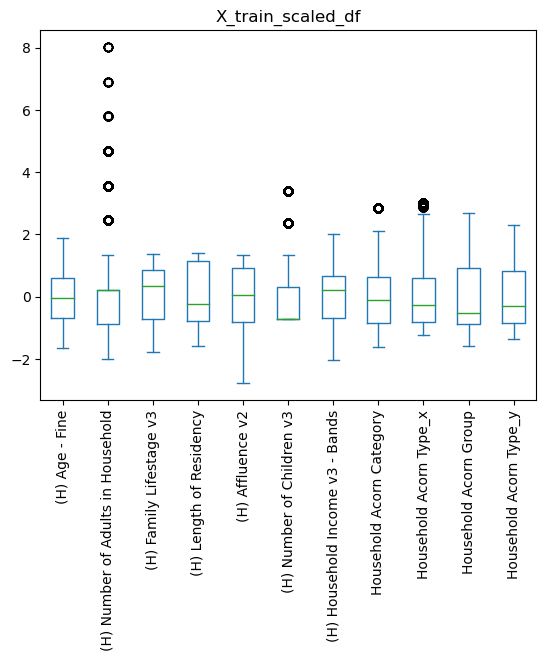

In [83]:
ax = X_train_scaled_df.plot.box()
plt.xticks(rotation=90)
plt.title('X_train_scaled_df')
plt.show()

In [73]:
X_train_Engineered = pd.merge(X_train_obj_ohe, X_train_scaled_df, left_index=True, right_index=True, how ='inner')

In [74]:
X_train_Engineered.head(2)

,ABP_Classification_Code_RD02,ABP_Classification_Code_RD03,ABP_Classification_Code_RD04,ABP_Classification_Code_RD06,Tenure_Desc_Council/HA,Tenure_Desc_Owner,Tenure_Desc_Rental,Local Custodian Name_Cherwell,Local Custodian Name_Oxford,Local Custodian Name_South Oxfordshire,...,(H) Number of Adults in Household,(H) Family Lifestage v3,(H) Length of Residency,(H) Affluence v2,(H) Number of Children v3,(H) Household Income v3 - Bands,Household Acorn Category,Household Acorn Type_x,Household Acorn Group,Household Acorn Type_y
0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,...,-0.882034,0.074357,0.597532,-0.604257,0.321069,-0.695950,-0.858029,-0.753330,1.261020,1.379655
1,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.231218,-0.187628,0.870543,0.476748,1.349961,1.106478,-0.858029,-0.821709,-0.867786,-1.042564


# PART 4: MODEL TRAINING

Finally, you train the model (for example logistic regression) using the processed training data, and then evaluate its performance using metrics such as accuracy, precision, recall, or ROC-AUC.

In [75]:
### Linear Regression Trial

In [76]:
X_train_Engineered.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 65851 entries, 0 to 65850
Data columns (total 23 columns):
 #   Column                                    Non-Null Count  Dtype  
---  ------                                    --------------  -----  
 0   ABP_Classification_Code_RD02              65851 non-null  float64
 1   ABP_Classification_Code_RD03              65851 non-null  float64
 2   ABP_Classification_Code_RD04              65851 non-null  float64
 3   ABP_Classification_Code_RD06              65851 non-null  float64
 4   Tenure_Desc_Council/HA                    65851 non-null  float64
 5   Tenure_Desc_Owner                         65851 non-null  float64
 6   Tenure_Desc_Rental                        65851 non-null  float64
 7   Local Custodian Name_Cherwell             65851 non-null  float64
 8   Local Custodian Name_Oxford               65851 non-null  float64
 9   Local Custodian Name_South Oxfordshire    65851 non-null  float64
 10  Local Custodian Name_Vale of White

In [77]:
from sklearn.linear_model import LinearRegression

In [78]:
lr_model = LinearRegression()
lr_model.fit(X_train_Engineered, y_train)

LinearRegression()

In [79]:
print(lr_model.score(X_train_Engineered, y_train))

0.012067793309674557


# LOGISTIC REGRESSION

In [80]:
from sklearn.linear_model import LogisticRegression
lg_model = LogisticRegression(max_iter =200)
lg_model.fit(X_train_Engineered, y_train)

LogisticRegression(max_iter=200)

In [81]:
print(lg_model.score(X_train_Engineered, y_train))

0.9692032011662693


# Other notes from Goncalo
4th March 2026
Regarding your specific question about the order of operations, I hope the answer is now clear. Conceptually, we split the data first, and then perform the preprocessing steps. The reason is that we want the preprocessing to be based only on the training data. However, in notebooks it can sometimes look easier to encode first and split afterwards. The important principle is simply that the transformations should be derived from the training data rather than the full dataset.

One reason the steps may currently feel disconnected is that the notebook is performing several techniques (pairplots, encoding, scaling, modelling) without yet tying them into a clear modelling pipeline. It may help to think about the purpose of each step. Exploratory analysis helps you understand the data. Encoding converts categorical variables into numbers so that models can use them. Scaling ensures numeric variables are on comparable ranges, which is important for algorithms such as logistic regression. The model then learns the relationship between the features and whether an incident occurs. From what you’ve shared, you are actually making good progress. You have inspected the dataset, reduced the number of features, identified the target variable, and started thinking about encoding and modelling. The next step is simply to organise these pieces into a clearer pipeline rather than treating them as completely separate experiments.

I hope that makes sense, but please feel free to share the results that you have so far. 

Kind regards,
Gonçalo
